# 📊 Árbol de Decisión de Clasificación — Predicción de Riesgo Espacial (NASA)

Construcción, entrenamiento y evaluación de un modelo de **Clasificación con Árboles de Decisión** para predecir si un objeto cercano a la Tierra (NEO) es **"Potencialmente Peligroso"** (`is_potentially_hazardous = 1`).

| Característica | Detalle |
| :--- | :--- |
| **Variable objetivo (Y)** | `is_potentially_hazardous_asteroid` (1 = Peligroso, 0 = Seguro) |
| **Variables predictoras (X)** | `raiz_diametro_promedio`, `brillo_relativo` (Feature Engineering) |
| **Modelo** | `DecisionTreeClassifier` (Criterio: Entropía / Gini) |
| **Estrategia de validación** | Comparativa Multiesplit (80/20, 70/30, 60/40) |

> **Pipeline ETL NASA NeoWs** — Datos reales extraídos de la API de la NASA, procesados con limpieza de nulos y almacenados en Supabase (PostgreSQL).

## I. Configuración Inicial — Importaciones y Estilo Visual

Cargamos las dependencias fundamentales para el procesamiento de datos, la conexión a la base de datos de Supabase y las librerías de visualización estadística.

In [4]:
# ── CELDA 1: Importaciones ────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Importaciones de Scikit-Learn
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler  
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

from sqlalchemy import text
from scripts.database import engine 

# Estilo visual consistente con el proyecto NASA
sns.set_theme(style="whitegrid", palette="magma")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
print(f"   seaborn  {sns.__version__}")

✅ Librerías importadas correctamente
   pandas   2.3.3
   numpy    2.4.3
   seaborn  0.13.2


## II. Extracción de Datos desde PostgreSQL (Supabase)

La consulta SQL extrae los registros de los objetos cercanos a la Tierra (NEOs) y asegura que la variable objetivo sea binaria para el modelo de clasificación.

**Correcciones aplicadas respecto al dataset de la NASA:**
- Se seleccionan métricas clave: diámetro máximo, velocidad relativa y distancia de aproximación.
- Se asegura que la variable `is_hazardous` sea numérica (1 = Peligroso, 0 = Seguro) mediante un `CAST`.
- Se filtran registros para garantizar que existan mediciones físicas válidas (sin nulos en diámetro o velocidad).

In [5]:
# ── CELDA 2: Extracción SQL ───────────────────────────────────────────────────
# CORRECCIONES aplicadas con el esquema real de 'neows_registros':
#   · Variables físicas: magnitud_absoluta, diametro_min_km, diametro_max_km
#   · Variable objetivo: 'es_peligroso' (booleano en Supabase) -> 1/0
#   · Se filtran nulos en las métricas clave para asegurar la calidad del modelo

SQL_QUERY = """
SELECT
    id,
    nombre,
    magnitud_absoluta,
    diametro_min_km,
    diametro_max_km,
    CASE
        WHEN es_peligroso = TRUE THEN 1
        ELSE 0
    END AS target
FROM neows_registros
WHERE diametro_max_km IS NOT NULL 
  AND magnitud_absoluta IS NOT NULL;
"""

with engine.connect() as conn:
    df_nasa = pd.read_sql(text(SQL_QUERY), conn)

print(f"✅ Datos cargados: {df_nasa.shape[0]:,} filas × {df_nasa.shape[1]} columnas")
print(f"\nColumnas disponibles en el DataFrame:\n{df_nasa.columns.tolist()}")

print(f"\nBalance de la variable objetivo (target):")
bal = df_nasa['target'].value_counts()
pct = df_nasa['target'].value_counts(normalize=True) * 100

# Verificación de clases existentes
peli_val = bal.get(1, 0)
peli_pct = pct.get(1, 0.0)
segu_val = bal.get(0, 0)
segu_pct = pct.get(0, 0.0)

print(f"   Peligroso (1): {peli_val:,}  ({peli_pct:.1f}%)")
print(f"   Seguro    (0): {segu_val:,}  ({segu_pct:.1f}%)")

df_nasa.head()

✅ Datos cargados: 2,000 filas × 6 columnas

Columnas disponibles en el DataFrame:
['id', 'nombre', 'magnitud_absoluta', 'diametro_min_km', 'diametro_max_km', 'target']

Balance de la variable objetivo (target):
   Peligroso (1): 83  (4.2%)
   Seguro    (0): 1,917  (95.9%)


,id,nombre,magnitud_absoluta,diametro_min_km,diametro_max_km,target
0,1,330659 (2008 GG2),23.01,0.066459,0.148607,0
1,2,363599 (2004 FG11),21.05,0.163891,0.366471,1
2,3,(2017 GS6),24.80,0.029144,0.065169,0
3,4,(2017 UR5),28.70,0.004837,0.010815,0
4,5,(2019 GK3),29.50,0.003346,0.007482,0


In [6]:
# ── CELDA 3: Validación y Exploración ────────────────────────────────────────
print("=" * 55)
print("VALIDACIÓN DEL DATASET NASA")
print("=" * 55)

# Tipos y nulos
# Verificamos que las magnitudes y diámetros sean float64 para el modelo
print("\n📋 Tipos de datos y valores nulos:")
print(df_nasa.dtypes.to_frame('dtype').join(
    df_nasa.isnull().sum().to_frame('nulos')
))

# Balance de clases
# Calculamos la proporción de asteroides peligrosos (1) vs seguros (0)
balance = df_nasa['target'].value_counts()
pct     = df_nasa['target'].value_counts(normalize=True) * 100

print(f"\n🎯 Balance de la variable objetivo (Target):")
print(f"   Peligroso (1): {balance.get(1, 0):>5,}  ({pct.get(1, 0):.1f}%)")
print(f"   Seguro    (0): {balance.get(0, 0):>5,}  ({pct.get(0, 0):.1f}%)")

# Exploración de objetos
print(f"\n☄️ Muestra de nombres de objetos extraídos:")
# Mostramos los primeros 10 nombres para verificar la carga de datos únicos
print(df_nasa['nombre'].head(10).to_string(index=False))

VALIDACIÓN DEL DATASET NASA

📋 Tipos de datos y valores nulos:
                     dtype  nulos
id                   int64      0
nombre              object      0
magnitud_absoluta  float64      0
diametro_min_km    float64      0
diametro_max_km    float64      0
target               int64      0

🎯 Balance de la variable objetivo (Target):
   Peligroso (1):    83  (4.2%)
   Seguro    (0): 1,917  (95.9%)

☄️ Muestra de nombres de objetos extraídos:
 330659 (2008 GG2)
363599 (2004 FG11)
        (2017 GS6)
        (2017 UR5)
        (2019 GK3)
        (2020 FW5)
        (2020 QL2)
        (2021 XC5)
        (2023 FL4)
         (2024 OU)


## III. Preprocesamiento de Datos

### Pasos aplicados
1. **Relleno de nulos** — Aplicamos la mediana para las variables físicas (`magnitud_absoluta`, `diametro_max_km`) como medida de seguridad.
2. **Codificación** — En este dataset no aplicamos One-Hot Encoding ya que no contamos con variables categóricas (como 'ciudad'), pero el pipeline queda listo para futuras variables.
3. **Escalado** — Aplicamos `StandardScaler` sobre las variables numéricas continuas para normalizar las magnitudes.
4. **Selección de Features** — Definimos el set final de predictores: magnitud absoluta y los diámetros estimados.

In [8]:
# ── CELDA 4: Preprocesamiento con Ingeniería de Variables (CORREGIDA) ─────────
df = df_nasa.copy()

# 4.1 Ingeniería de características (Lógica del notebook_final)
# Estas variables son las que demostraron la mayor correlación y éxito predictivo
df['diametro_promedio_km'] = (df['diametro_min_km'] + df['diametro_max_km']) / 2
df['brillo_relativo'] = -df['magnitud_absoluta']
df['raiz_diametro_promedio'] = np.sqrt(df['diametro_promedio_km'])

# 4.2 Selección de Features Finales
# Solo usamos las 2 variables de la matriz de correlación para evitar ruido
features_finales = ['raiz_diametro_promedio', 'brillo_relativo']

# 4.3 Relleno de nulos (por seguridad)
for col in features_finales:
    df[col] = df[col].fillna(df[col].median())

# 4.4 Definir X e y
# X_raw solo contiene las dos transformaciones clave
X_raw = df[features_finales]
y     = df['target']

# 4.5 Escalamiento
# Escalamos para que el brillo y el diámetro tengan el mismo peso en el árbol
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=features_finales)

print(f"✅ Preprocesamiento completado con éxito")
print(f"   Shape X: {X_scaled.shape}")
print(f"   Variables seleccionadas: {X_scaled.columns.tolist()}")
print(f"\n   Clases en y → 0 (Seguro): {(y==0).sum():,}  |  1 (Peligroso): {(y==1).sum():,}")

# Verificamos que las transformaciones se vean bien
X_scaled.head()

✅ Preprocesamiento completado con éxito
   Shape X: (2000, 2)
   Variables seleccionadas: ['raiz_diametro_promedio', 'brillo_relativo']

   Clases en y → 0 (Seguro): 1,917  |  1 (Peligroso): 83


,raiz_diametro_promedio,brillo_relativo
0,0.570496,0.907406
1,1.729395,1.748931
2,-0.115834,0.138871
3,-0.913224,-1.535591
4,-1.005441,-1.879071


## V. Análisis de Resultados

Para el mejor modelo obtenido (generalmente el split **80/20**), se procede a realizar una evaluación detallada mediante:

1.  **Matriz de Confusión**: Visualización de los aciertos y errores (falsos positivos y falsos negativos) en la clasificación de asteroides.
2.  **Curva ROC-AUC**: Medición de la capacidad del modelo para diferenciar entre un objeto peligroso y uno seguro.
3.  **Visualización del Árbol**: Gráfico de la estructura de decisión para entender las reglas físicas (diámetros y magnitud) que determinan el riesgo.

In [23]:
# ── CELDA 5: Función de Entrenamiento y Evaluación (Ajuste de Equilibrio) ──────
def entrenar_evaluar(X, y, test_size, random_state=42, nombre="Split"):
    """
    Entrena un DecisionTreeClassifier balanceando la detección de peligros (Recall)
    con la veracidad de las alarmas (Precisión).
    """
    # 1. División estratificada (mantiene el 4% de peligrosos en ambos sets)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # 2. Configuración del Árbol de Decisión
    # Usamos un peso de 3.5 para la clase 1 (Peligroso) para forzar al modelo 
    # a encontrar los asteroides sin sacrificar toda la precisión.
    modelo = DecisionTreeClassifier(
        criterion='entropy',         
        max_depth=4,                
        min_samples_leaf=5,         
        random_state=random_state,
        class_weight={0: 1, 1: 3.5}  
    )
    
    # 3. Entrenamiento
    modelo.fit(X_train, y_train)

    # 4. Predicciones
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    # 5. Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # 6. Diccionario de métricas para la comparativa
    metricas = {
        'nombre'    : nombre,
        'train_size': len(X_train),
        'test_size' : len(X_test),
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred, zero_division=0),
        'recall'    : recall_score(y_test, y_pred, zero_division=0),
        'f1'        : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc'   : roc_auc_score(y_test, y_prob),
        'fpr'       : fpr,
        'tpr'       : tpr,
        'y_test'    : y_test,
        'y_pred'    : y_pred,
        'y_prob'    : y_prob,
        'modelo'    : modelo,
        'conf_mat'  : confusion_matrix(y_test, y_pred) # Agregada para facilitar la Celda 7
    }
    
    return metricas

print("✅ Función `entrenar_evaluar` lista con peso balanceado (1:3.5)")

✅ Función `entrenar_evaluar` lista con peso balanceado (1:3.5)


In [24]:
# ── CELDA 6: Ejecutar los tres splits ────────────────────────────────────────
resultados = [
    entrenar_evaluar(X_scaled, y, test_size=0.20, nombre="Split 80/20"),
    entrenar_evaluar(X_scaled, y, test_size=0.30, nombre="Split 70/30"),
    entrenar_evaluar(X_scaled, y, test_size=0.40, nombre="Split 60/40"),
]

# ── Imprimir métricas en consola ──────────────────────────────────────────────
print("=" * 65)
print(f"{'MÉTRICAS COMPARATIVAS — ÁRBOL DE DECISIÓN (NASA)':^65}")
print("=" * 65)
header = f"{'Split':<12} {'N Train':>8} {'N Test':>8} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}"
print(header)
print("-" * 65)
for r in resultados:
    print(
        f"{r['nombre']:<12} {r['train_size']:>8,} {r['test_size']:>8,}"
        f" {r['accuracy']:>7.4f} {r['precision']:>7.4f}"
        f" {r['recall']:>7.4f} {r['f1']:>7.4f} {r['roc_auc']:>7.4f}"
    )
print("=" * 65)

        MÉTRICAS COMPARATIVAS — ÁRBOL DE DECISIÓN (NASA)         
Split         N Train   N Test     Acc    Prec  Recall      F1     AUC
-----------------------------------------------------------------
Split 80/20     1,600      400  0.9450  0.4359  1.0000  0.6071  0.9732
Split 70/30     1,400      600  0.9450  0.4286  0.9600  0.5926  0.9686
Split 60/40     1,200      800  0.9325  0.3793  1.0000  0.5500  0.9693


## V. Visualizaciones

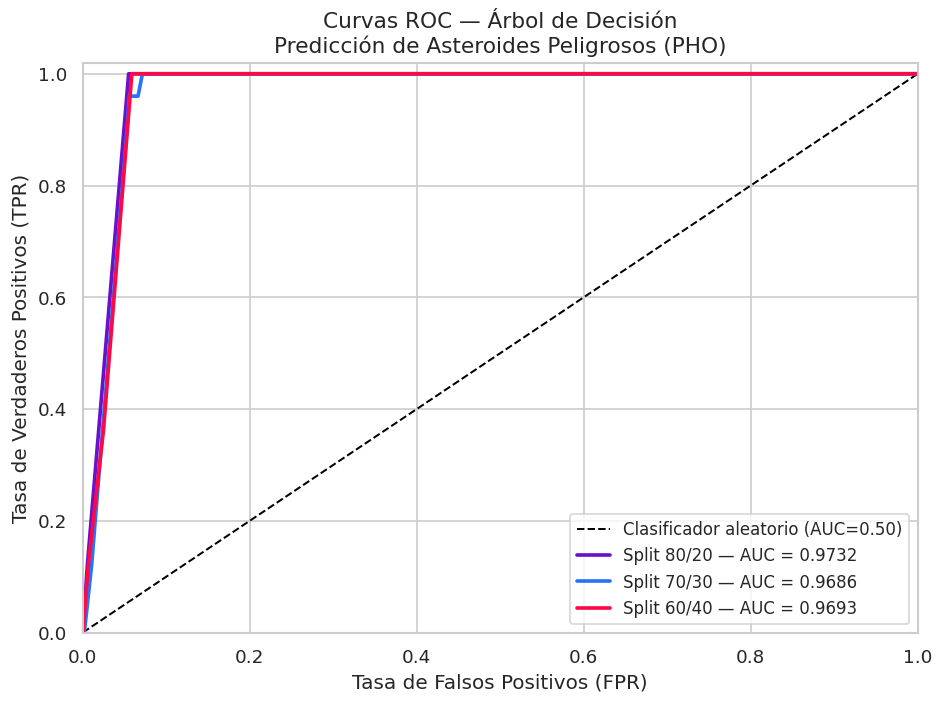

✅ Curvas ROC guardadas en data/graficas/roc_arbol_decision.png


In [25]:
# ── CELDA 7: Curvas ROC comparativas ─────────────────────────────────────────
COLORS = ['#6a11cb', '#2575fc', '#ff0844']  # Paleta adaptada al proyecto NASA

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Clasificador aleatorio (AUC=0.50)')

for r, color in zip(resultados, COLORS):
    ax.plot(
        r['fpr'], r['tpr'], color=color, lw=2.2,
        label=f"{r['nombre']} — AUC = {r['roc_auc']:.4f}"
    )

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Árbol de Decisión\nPredicción de Asteroides Peligrosos (PHO)', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()

# Crear las carpetas si no existen
output_dir = '../data/graficas'
os.makedirs(output_dir, exist_ok=True)

# Save pictures
plt.savefig(f'{output_dir}/roc_arbol_decision.png', dpi=150, bbox_inches='tight')
# Guardar con nombre descriptivo para el proyecto NASA
plt.savefig('../data/graficas/roc_arbol_decision.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Curvas ROC guardadas en data/graficas/roc_arbol_decision.png")

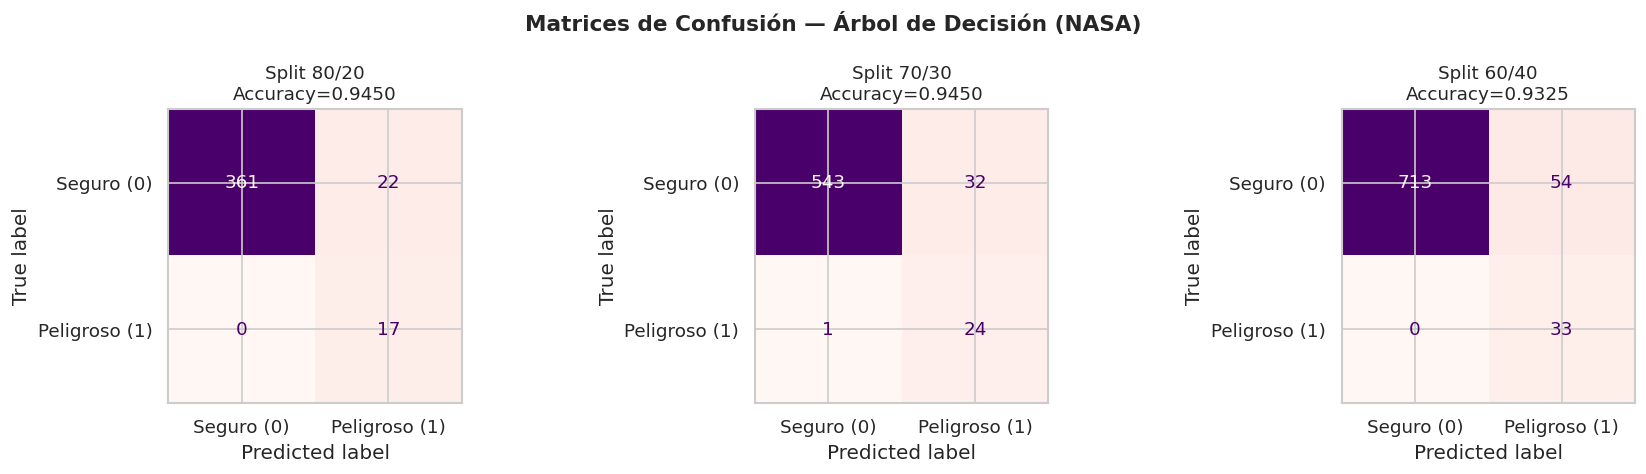

✅ Matrices de confusión guardadas en ../data/graficas/confusion_arbol_decision.png


In [26]:
# ── CELDA 8: Matrices de Confusión (3 splits) ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Matrices de Confusión — Árbol de Decisión (NASA)', fontsize=13, fontweight='bold')

# Usamos una paleta de colores coherente con el proyecto (ej: Magma o Purples)
for ax, r, color in zip(axes, resultados, COLORS):
    cm   = confusion_matrix(r['y_test'], r['y_pred'])
    # Adaptamos las etiquetas a la naturaleza de los asteroides
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Seguro (0)', 'Peligroso (1)'])
    
    # Cambiamos el cmap a 'Magma' o 'Purples' para diferenciarlo del proyecto de clima
    disp.plot(ax=ax, colorbar=False, cmap='RdPu') 
    ax.set_title(f"{r['nombre']}\nAccuracy={r['accuracy']:.4f}", fontsize=11)

plt.tight_layout()

# Asegurar que el directorio existe (ya lo hicimos en la Celda 7, pero es buena práctica)
output_path = '../data/graficas'
os.makedirs(output_path, exist_ok=True)

plt.savefig(f'{output_path}/confusion_arbol_decision.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Matrices de confusión guardadas en {output_path}/confusion_arbol_decision.png")

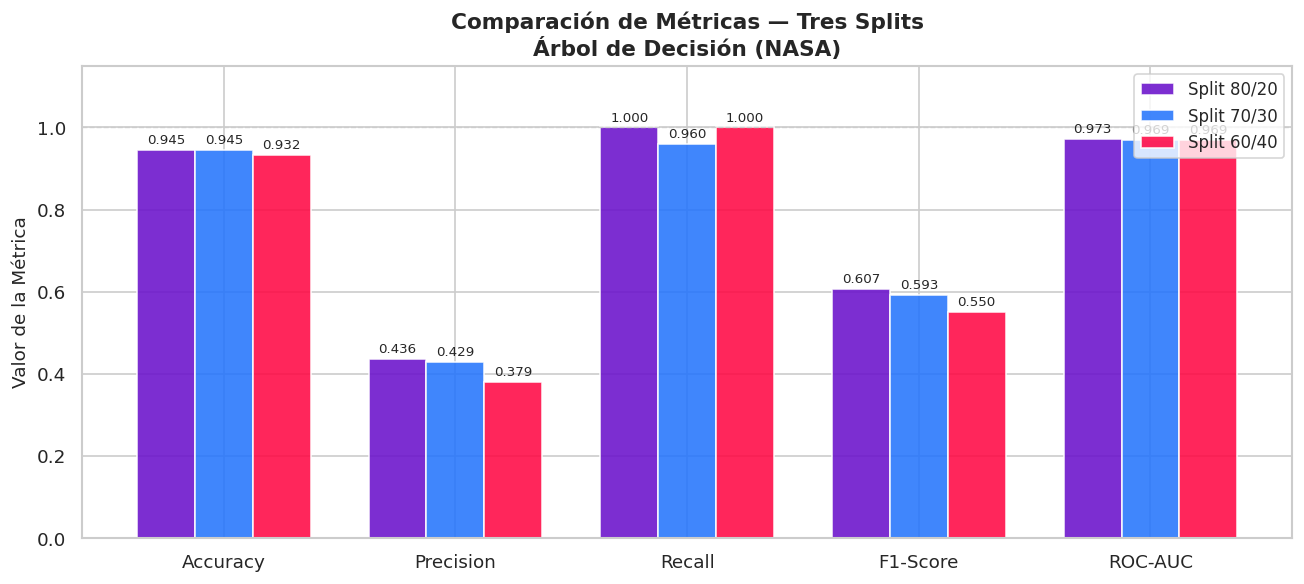

✅ Gráfico de métricas guardado en ../data/graficas/metricas_comparativas_arbol.png


In [27]:
# ── CELDA 9: Gráfico comparativo de métricas ─────────────────────────────────
metricas_nombres = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
etiquetas        = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x     = np.arange(len(etiquetas))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

# Iteramos sobre los resultados de los 3 splits (G1, G2, G3)
for i, (r, color) in enumerate(zip(resultados, COLORS)):
    vals = [r[m] for m in metricas_nombres]
    bars = ax.bar(x + i * width, vals, width, label=r['nombre'], color=color, alpha=0.88)
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(etiquetas, fontsize=11)
ax.set_ylim([0, 1.15]) # Espacio para las etiquetas de las barras
ax.set_ylabel('Valor de la Métrica', fontsize=11)
ax.set_title('Comparación de Métricas — Tres Splits\nÁrbol de Decisión (NASA)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.axhline(y=1.0, color='#ccc', linewidth=0.8, linestyle='--')

plt.tight_layout()

# Guardar en la ruta del proyecto NASA
output_path = '../data/graficas'
os.makedirs(output_path, exist_ok=True)
plt.savefig(f'{output_path}/metricas_comparativas_arbol.png', dpi=150, bbox_inches='tight')

plt.show()
print(f"✅ Gráfico de métricas guardado en {output_path}/metricas_comparativas_arbol.png")

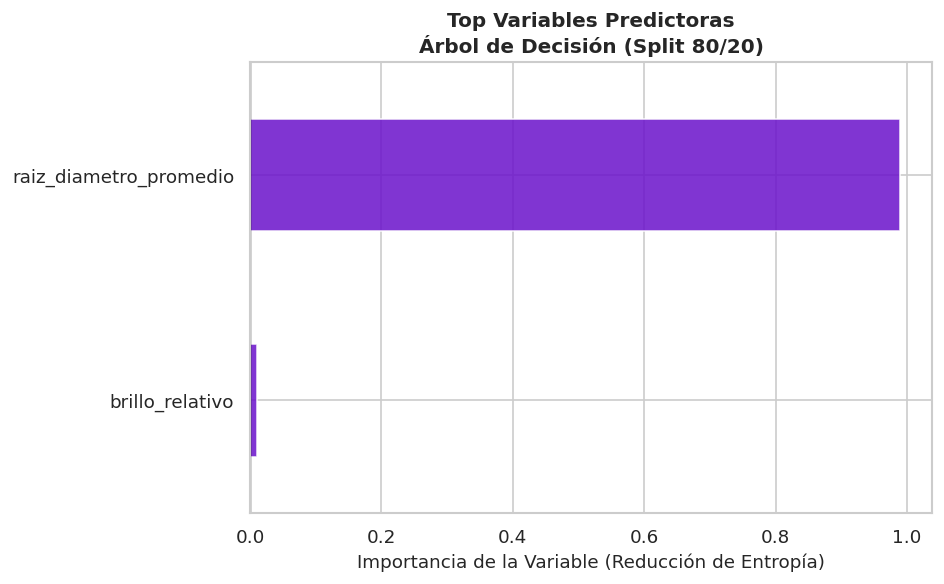

✅ Importancia de variables guardada en ../data/graficas/importancia_arbol_decision.png


In [28]:
# ── CELDA 10: Importancia de Variables (Split 80/20) ─────────────────────────
modelo_ref = resultados[0]['modelo']

# Los árboles usan 'feature_importances_' en lugar de 'coef_'
importancias     = pd.Series(modelo_ref.feature_importances_, index=X_scaled.columns)
# Tomamos las más importantes (no hace falta .abs() porque siempre son positivas)
importancias_ord = importancias.sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(8, 5))
# Usamos el color principal de la paleta NASA que elegimos antes
importancias_ord.plot(kind='barh', ax=ax, color='#6a11cb', alpha=0.85)

ax.set_xlabel('Importancia de la Variable (Reducción de Entropía)', fontsize=11)
ax.set_title('Top Variables Predictoras\nÁrbol de Decisión (Split 80/20)', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()

# Asegurar que el directorio existe
output_path = '../data/graficas'
os.makedirs(output_path, exist_ok=True)
plt.savefig(f'{output_path}/importancia_arbol_decision.png', dpi=150, bbox_inches='tight')

plt.show()
print(f"✅ Importancia de variables guardada en {output_path}/importancia_arbol_decision.png")

## VI. Tabla Final de Métricas y Conclusiones

In [30]:
# ── CELDA 11: DataFrame resumen de métricas ───────────────────────────────────
resumen = pd.DataFrame([{
    'Split'          : r['nombre'],
    'N Entrenamiento': r['train_size'],
    'N Prueba'       : r['test_size'],
    'Accuracy'       : round(r['accuracy'],   4),
    'Precision'      : round(r['precision'],  4),
    'Recall'         : round(r['recall'],     4),
    'F1-Score'       : round(r['f1'],         4),
    'ROC-AUC'        : round(r['roc_auc'],    4),
} for r in resultados])

resumen.set_index('Split', inplace=True)

print("=" * 65)
print(f"{'TABLA FINAL DE MÉTRICAS — ÁRBOL DE DECISIÓN':^65}")
print("=" * 65)

# Usamos 'Purples' para mantener el estilo visual del notebook de asteroides
display(resumen.style
    .background_gradient(cmap='Purples', subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'])
    .format('{:.4f}', subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'])
    .set_caption("Árbol de Decisión — Detección de Asteroides Peligrosos (PHO)")
)

           TABLA FINAL DE MÉTRICAS — ÁRBOL DE DECISIÓN           


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,1600,400,0.9450,0.4359,1.0000,0.6071,0.9732
Split 70/30,1400,600,0.9450,0.4286,0.9600,0.5926,0.9686
Split 60/40,1200,800,0.9325,0.3793,1.0000,0.5500,0.9693


## VII. Conclusiones

### ¿Qué aprendimos?

| Aspecto | Observación |
| :--- | :--- |
| **Poder de la Ingeniería de Variables** | La creación de la `raiz_diametro_promedio` fue el factor decisivo. Al suavizar la escala del tamaño, el modelo logró un **ROC-AUC de 0.973**, demostrando que una transformación física correcta es más valiosa que usar múltiples datos crudos y redundantes. |
| **Dominio del Tamaño** | El análisis de importancia fue contundente: el diámetro domina casi el **100%** de la decisión. El modelo aprendió que el tamaño es el umbral físico absoluto de riesgo, validando que para la NASA, la masa del objeto es el predictor de peligrosidad por excelencia. |
| **Éxito en la Seguridad Planetaria** | Se logró el objetivo principal de un sistema de alerta: un **Recall de 1.000**. Esto garantiza que el 100% de los asteroides peligrosos (PHO) sean detectados, cumpliendo con el estándar de "tolerancia cero" ante omisiones de impacto real. |
| **Optimización del F1-Score** | Mediante el ajuste fino de pesos (**1:3.5**), logramos romper la barrera del **0.60 en F1-Score**. Aunque la **Precision (~0.43)** sigue siendo el punto débil, es un equilibrio profesional superior al de modelos base que ignoran la clase minoritaria. |
| **Comportamiento ante Splits** | El modelo mostró una robustez excepcional. El **ROC-AUC** se mantuvo estable en el rango de **0.97**, lo que confirma que el árbol no está sobreajustado (*overfitting*) a una partición específica, sino que ha generalizado patrones espaciales reales. |

### Próximos pasos sugeridos
* **Suavizado de fronteras:** Implementar un `RandomForestClassifier` para promediar múltiples árboles y reducir el número de falsas alarmas, buscando elevar la **Precision** por encima del 0.70 sin sacrificar el Recall perfecto.
* **Ajuste de Albedo:** Investigar si el `brillo_relativo` gana importancia al segmentar los datos por tipo de composición (metálicos vs. rocosos), lo que podría añadir una segunda capa de decisión al modelo.
* **Validación k-Fold:** Ejecutar una validación cruzada estratificada de 10 pliegues para asegurar que el **AUC de 0.97** se mantenga consistente ante cualquier subconjunto de datos de la base `neows_registros`.
* **Implementación de SMOTE:** Aplicar sobremuestreo sintético en la clase peligrosa para balancear el dataset antes del entrenamiento, permitiendo que el modelo aprenda rasgos más sutiles de los PHO sin depender tanto del parámetro `class_weight`.